# Linear Regression — Complete Guide (From Scratch to Scikit-Learn)

This notebook brings together the full Linear Regression journey in one place:

1. **Simple Linear Regression** — one input feature ($y = wx + b$). We build the
   prediction function, manually tune parameters, define the cost function, and
   implement **Gradient Descent** from scratch to learn the best fit automatically.
2. **Multiple Linear Regression** — many input features
   ($y = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$), implemented in a vectorized way
   with NumPy.
3. **Scikit-Learn** — the industry-standard way using `LinearRegression` and
   `SGDRegressor`, compared against our from-scratch results.

The goal is intuition first (what the math is doing), then the practical tools.

4. **Real-dataset validation** — the same simple/multiple regression ideas re-run on
   scikit-learn's real Diabetes dataset, with R² and Adjusted R².
5. **Manual OLS (Normal Equation)** — the closed-form solution
   $\beta = (X^TX)^{-1}X^Ty$, computed by hand and checked against scikit-learn.
6. **Multicollinearity check** — correlation matrix and Variance Inflation Factor (VIF).
7. **Residual diagnostics** — residuals-vs-fitted and residual-distribution plots.
8. **Polynomial regression** — extending the same technique to curved relationships.


## 0. Imports & Setup
We rely on three libraries throughout:
- **NumPy** for numerical arrays and fast math.
- **Matplotlib** for plotting.
- **Seaborn** for prettier statistical plots (built on top of Matplotlib).

In [1]:
import numpy as np                 # Handling numerical arrays
import matplotlib.pyplot as plt    # Creating plots
import seaborn as sns              # Prettier statistical plots (built on matplotlib)

# Set a clean default style for all our plots
sns.set_theme()

---
# Part 1 — Simple Linear Regression

A **simple** linear regression model maps a single input feature `X` to a target
`y` using a straight line:

$$ f(x) = wx + b $$

- $w$ (**weight**) controls the **slope** of the line.
- $b$ (**bias**) controls the **y-intercept** (shifts the line up/down).

Our job is to find the $w$ and $b$ that make the line fit the data as closely as
possible.

## 1.1 Setup Data
We define our input feature `X` (Years of Experience) and our target label `y`
(Salary, in thousands).

In [2]:
# X represents our 'Feature' (the data we use to make predictions)
X = np.array([1, 3, 4, 6, 7])    # Years of experience

# y represents our 'Target' (the value we want the model to learn to predict)
y = np.array([15, 35, 45, 65, 75])  # Salary in thousands

## 1.2 Visualize the Raw Data
Before modeling, we look at the data points to check whether a (linear)
relationship exists between experience and salary.

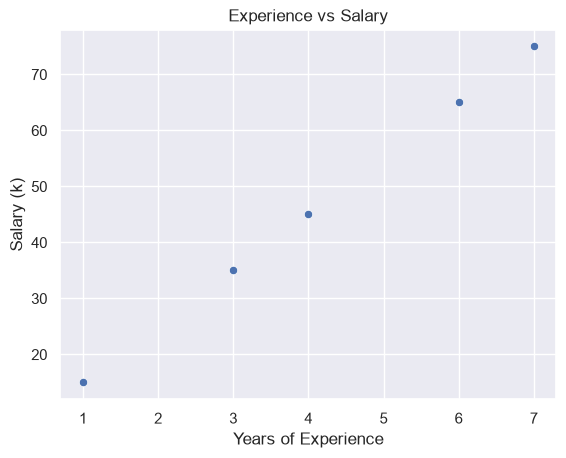

In [3]:
# Scatter plot to see the relationship between X and y
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.title("Experience vs Salary")
plt.show()

## 1.3 The Prediction Function
The function below implements the linear formula $f(x) = wx + b$ for every data
point.

In [4]:
def make_prediction(X, y, w, b):
  """
  Calculates predictions using the linear regression formula: y = wx + b
  w: weight (slope)
  b: bias (intercept)
  """
  m = X.shape[0]            # Number of training examples
  pred_list = np.zeros((m,))  # Empty array to store our results

  for i in range(m):
    # Prediction for each specific data point
    pred_list[i] = w * X[i] + b

  return pred_list

## 1.4 Experimenting with Parameters
Now we test different values of `w` and `b` to see how well the resulting line
fits the data. This builds intuition for what $w$ and $b$ actually do, before we
automate the search.

Predictions (w=0, b=0): [0. 0. 0. 0. 0.]


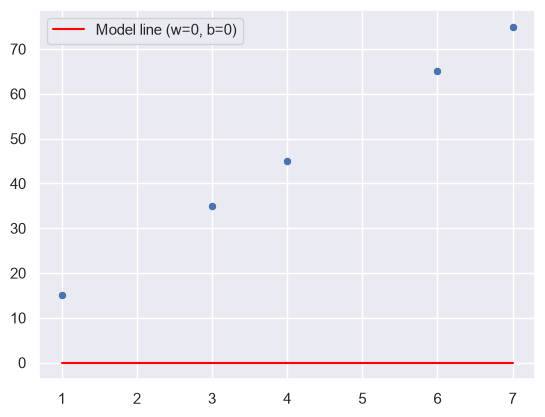

In [5]:
# Start with w=0 and b=0 (a flat line sitting at zero)
predictions = make_prediction(X, y, 0, 0)
print(f"Predictions (w=0, b=0): {predictions}")

# Visualize how this 'zero' model fits the data
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=0, b=0)')
plt.legend()
plt.show()

### Case 1: Minimal slope
Here $w=1, b=0$. The line is far below the data points — the slope is too small.

Predictions (w=1, b=0): [1. 3. 4. 6. 7.]


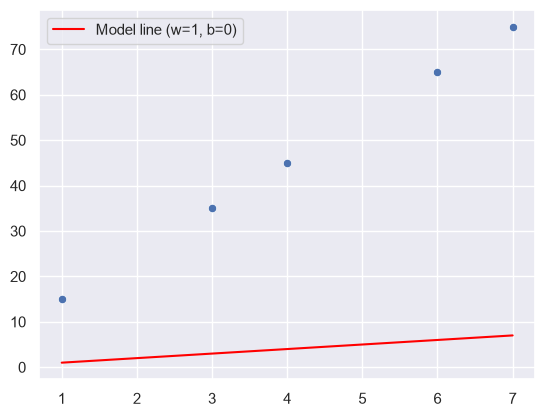

In [6]:
predictions = make_prediction(X, y, w=1, b=0)
print(f"Predictions (w=1, b=0): {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=1, b=0)')
plt.legend()
plt.show()

### Case 2: Increasing the slope
Using $w=5, b=3$ brings the line closer, but it's still not quite there.

Predictions (w=5, b=3): [ 8. 18. 23. 33. 38.]


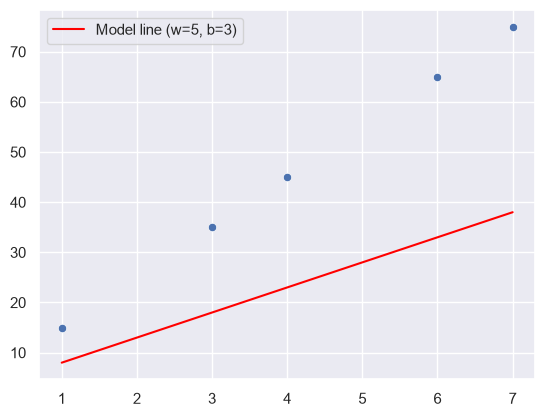

In [7]:
predictions = make_prediction(X, y, w=5, b=3)
print(f"Predictions (w=5, b=3): {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=5, b=3)')
plt.legend()
plt.show()

### Case 3: Finding a good fit by hand
With $w=10, b=5$, we see a much better alignment with the data points — in fact,
for this small dataset it's a perfect fit.

Predictions (w=10, b=5): [15. 35. 45. 65. 75.]


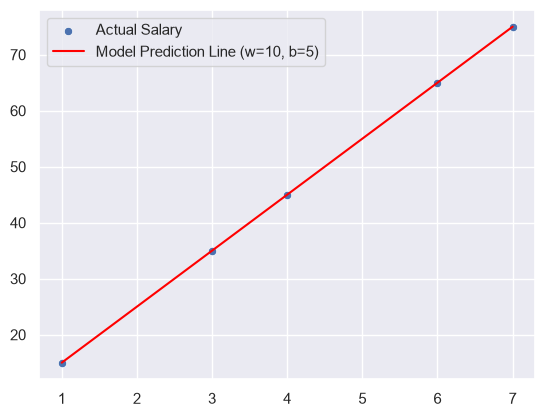

In [8]:
predictions = make_prediction(X, y, w=10, b=5)
print(f"Predictions (w=10, b=5): {predictions}")

# Plot the actual data points
sns.scatterplot(x=X, y=y, label='Actual Salary')
# Draw the model's prediction line
plt.plot(X, predictions, color='red', label='Model Prediction Line (w=10, b=5)')
plt.legend()
plt.show()

## 1.5 Cost Function (Mean Squared Error)
Eyeballing the line works for a tiny dataset, but we need a **number** that tells
us how good a fit is. That is the **cost** — here we use Mean Squared Error (MSE):

$$ J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f(x^{(i)}) - y^{(i)} \right)^2 $$

A **lower cost means a better fit**. We divide by $2m$ instead of $m$ purely for
mathematical convenience — the $2$ cancels nicely when we take derivatives during
gradient descent.

In [9]:
def compute_cost(X, y, w, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy."""
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]   # Difference between prediction and actual value
    error_squared = error ** 2
    cost = cost + error_squared

  # Divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

## 1.6 Visualizing the Cost
Let's attach the cost to a few candidate lines, then plot how the cost changes as
we sweep the weight $w$ (keeping $b$ fixed). The result is a convex, **U-shaped**
curve — and the lowest point of that "U" is exactly the $w$ we want.

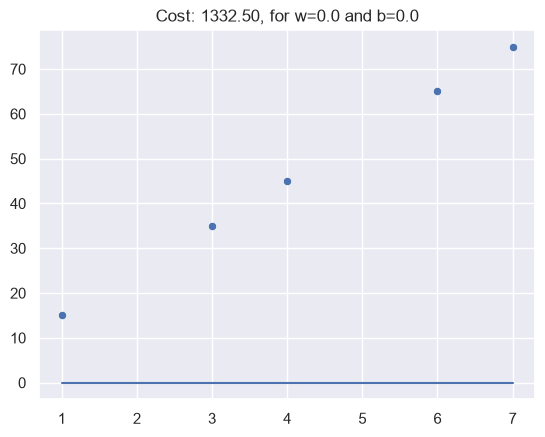

In [10]:
w = 0.0
b = 0.0

predictions = make_prediction(X, y, w=w, b=b)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
# The title shows the cost, helping us see how 'wrong' this line is
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[1. 3. 4. 6. 7.]


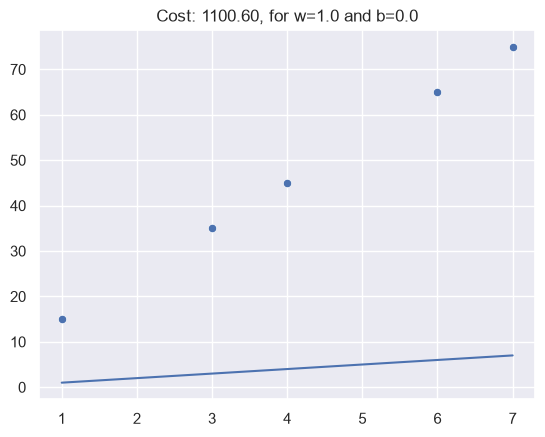

In [11]:
w = 1.0
b = 0.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[ 3.  7.  9. 13. 15.]


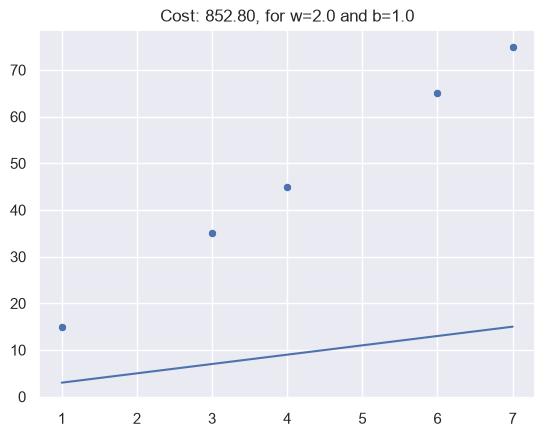

In [12]:
w = 2.0
b = 1.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[15. 35. 45. 65. 75.]


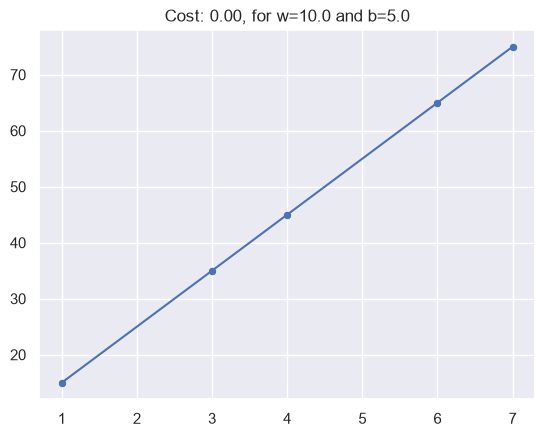

In [13]:
w = 10.0
b = 5.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

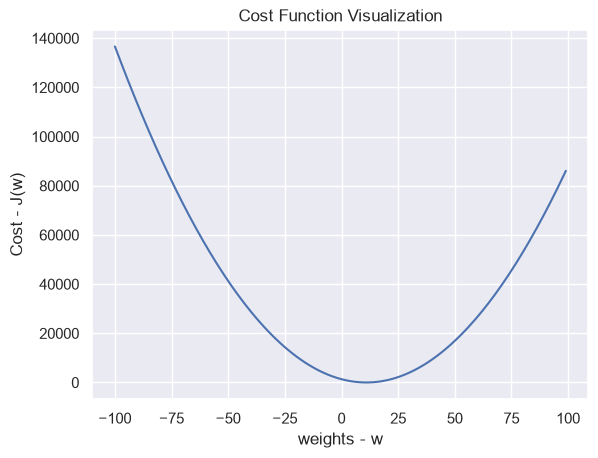

In [14]:
w_range = []
cost_history = []

# Loop through different weight values to see how each affects the cost
for i in range(-100, 100):
    cost_i = compute_cost(X, y, w=i, b=0)
    w_range.append(i)
    cost_history.append(cost_i)

# Plotting the Cost Function: the goal of ML is to find the bottom of this 'U'
plt.plot(w_range, cost_history)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

## 1.7 Gradient Descent
Instead of guessing parameter values, we use the **gradient** (the slope of the
cost curve) to know which direction to nudge $w$ and $b$ so the cost goes *down*.

The partial derivatives of the cost are:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(f(x^{(i)}) - y^{(i)})\,x^{(i)}
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(f(x^{(i)}) - y^{(i)}) $$

We then repeatedly update the parameters by a small step (the **learning rate**
$\alpha$) against the gradient:

$$ w := w - \alpha \frac{\partial J}{\partial w} \qquad b := b - \alpha \frac{\partial J}{\partial b} $$

In [15]:
def calculate_gradient(X, y, w, b):
  """Computes the gradient (direction to move) for w and b."""
  m = X.shape[0]
  dj_dw = 0.0   # Change needed for the weight
  dj_db = 0.0   # Change needed for the bias

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    # Multiply error by X[i] for the weight gradient
    dj_dw = dj_dw + (error * X[i])
    # The bias gradient is just the sum of errors
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [16]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize the cost."""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Run Gradient Descent
We initialize $w$ and $b$ at 0 and let the algorithm find the best values.

In [17]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(
    X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01
)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

Notice how the gradients (`dj_dw`, `dj_db`) and the cost shrink toward zero over
the iterations. Once the algorithm **converges** to the minimum point of the cost
function, the updates become tiny and it effectively stops changing $w$ and $b$.

## 1.8 Final Results & Prediction
With the optimized parameters we can draw the best-fit line and predict the salary
for a brand-new input (e.g. someone with 2 years of experience).

Optimized w: 10.0000, b: 5.0000


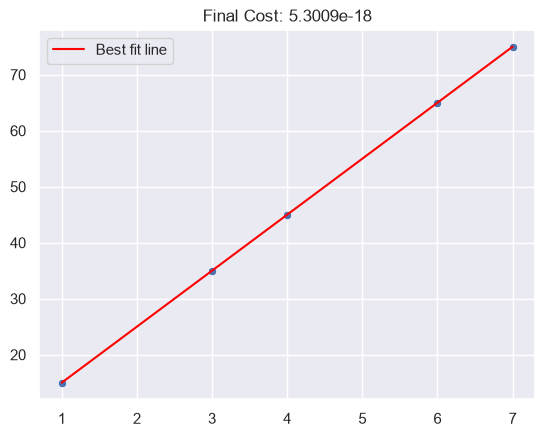

In [18]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [19]:
# Example: predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 25.00k


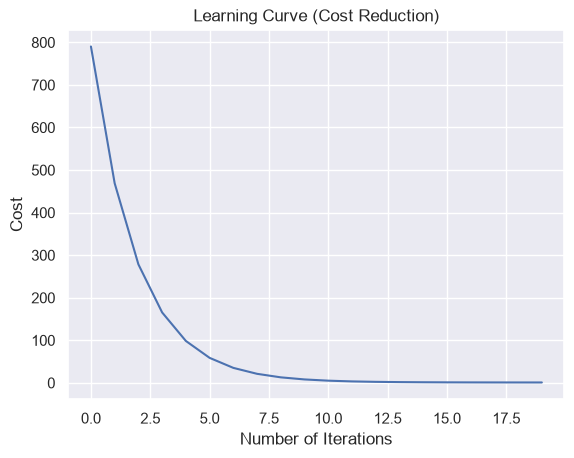

In [20]:
# Plot the cost over the first 20 iterations to see it dropping fast (learning curve)
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

---
# Part 2 — Multiple Linear Regression

Real problems rarely depend on a single feature. **Multiple** linear regression
extends the same idea to many input features:

$$ f(\mathbf{x}) = w_1x_1 + w_2x_2 + \dots + w_nx_n + b = \mathbf{w}\cdot\mathbf{x} + b $$

The structure is identical — prediction, cost, gradient descent — but now $\mathbf{w}$
is a **vector** of weights (one per feature) and we use the dot product.

## 2.1 Data Preparation
Each row of `X` is one person; each column is a feature:

| Column | Feature |
|--------|---------|
| 0 | Years of Experience |
| 1 | Problem-Solving (PS) Skill |
| 2 | Pause Time During Interview |
| 3 | GPA |

The target `y` is Salary. (This synthetic data was generated with true weights
`w = [5, 10, -2, 0.5]` and `b = 2.0`, so we have a known answer to check against.)

In [21]:
X = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [5, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])

# True parameters used to generate y:  w = [5, 10, -2, 0.5] , b = 2.0
y = np.array([45.9, 76.55, 92.35, 107.9, 128.])

Let's visualize each feature against the target to sanity-check the relationships.

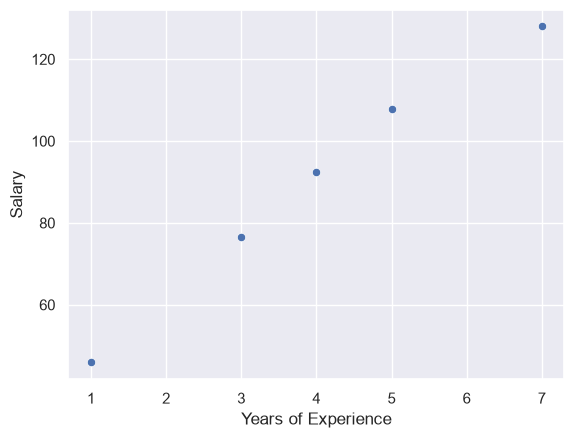

In [22]:
# Feature 0: Years of Experience
sns.scatterplot(x=X[:, 0:1].ravel(), y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

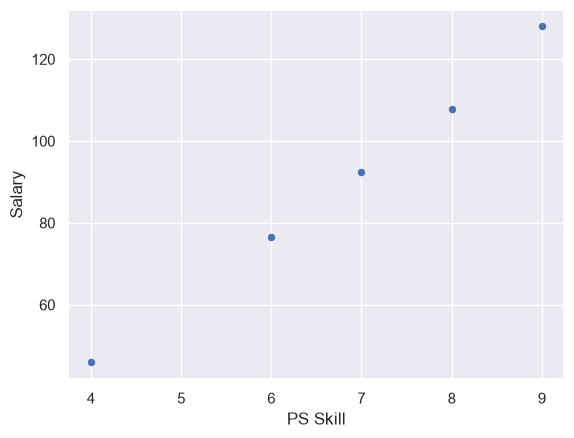

In [23]:
# Feature 1: Problem-Solving Skill
sns.scatterplot(x=X[:, 1:2].ravel(), y=y)
plt.xlabel("PS Skill")
plt.ylabel("Salary")
plt.show()

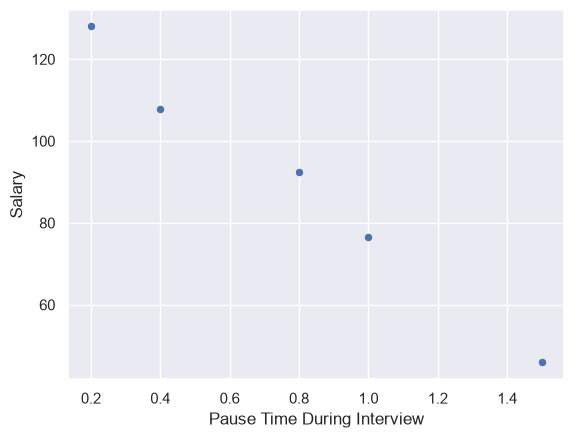

In [24]:
# Feature 2: Pause Time During Interview
sns.scatterplot(x=X[:, 2:3].ravel(), y=y)
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
plt.show()

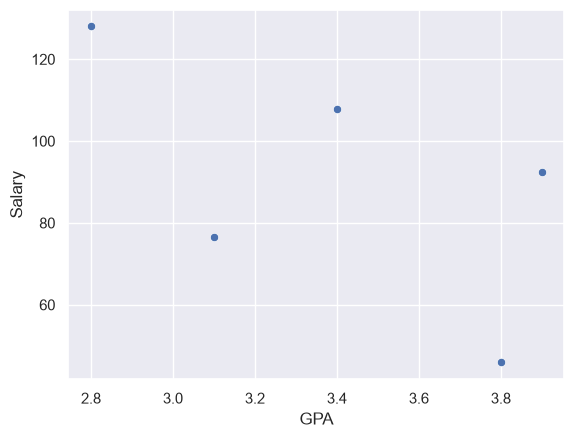

In [25]:
# Feature 3: GPA
sns.scatterplot(x=X[:, 3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

## 2.2 Manual Implementation (Vectorized)
We rebuild the same three components, now generalized to $n$ features:

1. **Prediction** — $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$ (dot product).
2. **Cost** — Mean Squared Error, computed with vectorized NumPy operations.
3. **Gradient Descent** — adjusts the weight *vector* $\mathbf{w}$ and bias $b$.

### Prediction function
Note the signature changes to `(X, W, b)` and uses `np.dot(W, X[i])` so it works
for any number of features.

In [26]:
def make_prediction(X, W, b):
  """Calculates the model output: f(x) = W·x + b (for multiple features)."""
  m = X.shape[0]            # Number of training examples
  pred_list = np.zeros((m,))  # Initialize an array to store results

  for i in range(m):
    # X[i] = feature vector for one example, W = weights vector
    pred_list[i] = np.dot(W, X[i]) + b

  return pred_list

In [27]:
m = X.shape[0]   # number of examples
n = X.shape[1]   # number of features

# Quick sanity check with all-ones weights and bias = 1.0
W_init = np.ones((n,))
b_init = 1.0

make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

### Cost function (vectorized)
Same MSE as before, but computed on whole arrays instead of a Python loop.

In [28]:
def compute_cost(X, y, W, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy."""
  m = X.shape[0]

  pred_list = make_prediction(X, W, b)

  error = pred_list - y
  error_squared = error ** 2
  cost = np.sum(error_squared)

  # Divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

In [29]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X, y, W_init, b_init)

np.float64(3060.2095)

### Gradient function
`dj_dw` is now a **vector** with one partial derivative per feature. For each
example we accumulate `error * X[i, j]` into the gradient of feature `j`.

In [30]:
def calculate_gradient(X, y, W, b):
  """Computes the gradient (direction to move) for the weight vector W and bias b."""
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,))   # one gradient per feature (n features -> n weights)
  dj_db = 0.0              # Change needed for the bias

  for i in range(m):
    prediction = np.dot(W, X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db + error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i, j])

  return dj_dw / m, dj_db / m

In [31]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X, y, W_init, b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

### Gradient descent loop
Identical structure to the simple case; it just happens to update a vector `w`.

In [32]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w (vector) and b to minimize the cost."""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, dj_dw: {dj_dw}, dj_db: {dj_db}, w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Training the Model
We initialize the weights to zero and run the gradient descent loop for many
iterations to find the optimal values.

In [33]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(
    X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01
)

Iteration 0: Cost 188.4458, dj_dw: [-416.09  -660.91   -57.608 -299.43 ], dj_db: -90.14, w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977, dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154], dj_db: 0.08612436152810829, w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303, dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368], dj_db: 0.007027042739039757, w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229, dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236], dj_db: 0.0014341624474738524, w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162, dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ], dj_db: 0.0010265453320059236, w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098, dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513], dj_db: 0.0009845325017124652, w: [ 6.7392106   8.50700022 -0

Iteration 4600: Cost 0.0112, dj_dw: [ 0.01571925 -0.01477176  0.00818589  0.00906099], dj_db: 0.00039089145924720015, w: [ 5.52754634  9.65137218 -1.1568744   0.78127029], b: 0.6469
Iteration 4700: Cost 0.0106, dj_dw: [ 0.01528337 -0.01435889  0.0079784   0.00879919], dj_db: 0.0003786709178257297, w: [ 5.51204823  9.66593446 -1.16495506  0.77234215], b: 0.6465
Iteration 4800: Cost 0.0100, dj_dw: [ 0.01485958 -0.01395753  0.00777623  0.00854494], dj_db: 0.0003666063430870281, w: [ 5.49697986  9.68008972 -1.17283093  0.76367197], b: 0.6462
Iteration 4900: Cost 0.0095, dj_dw: [ 0.01444755 -0.01356738  0.00757923  0.00829803], dj_db: 0.0003546984384612983, w: [ 5.48232932  9.6938493  -1.18050724  0.75525232], b: 0.6458
Iteration 5000: Cost 0.0090, dj_dw: [ 0.01404695 -0.01318811  0.00738727  0.00805823], dj_db: 0.0003429477508760215, w: [ 5.46808501  9.70722425 -1.18798912  0.74707598], b: 0.6455
Iteration 5100: Cost 0.0085, dj_dw: [ 0.01365746 -0.01281942  0.00720024  0.00782534], dj_db: 

Iteration 8300: Cost 0.0016, dj_dw: [ 0.0055543  -0.00516697  0.00318816  0.00305814], dj_db: 4.060196834103636e-05, w: [ 5.16607491  9.98974497 -1.3526788   0.57676457], b: 0.6396
Iteration 8400: Cost 0.0015, dj_dw: [ 0.00540031 -0.005022    0.00310883  0.00296953], dj_db: 3.38194474750253e-05, w: [ 5.16059874  9.99483839 -1.35582672  0.5737514 ], b: 0.6395
Iteration 8500: Cost 0.0015, dj_dw: [ 0.00525059 -0.00488108  0.00303154  0.00288348], dj_db: 2.7160229635114774e-05, w: [ 5.1552744   9.99978889 -1.35889635  0.57082554], b: 0.6395
Iteration 8600: Cost 0.0014, dj_dw: [ 0.00510501 -0.00474408  0.00295624  0.00279991], dj_db: 2.062270484657347e-05, w: [ 5.15009767 10.00460046 -1.36188969  0.56798446], b: 0.6395
Iteration 8700: Cost 0.0013, dj_dw: [ 0.00496347 -0.00461091  0.00288287  0.00271876], dj_db: 1.4205258592880909e-05, w: [ 5.14506446 10.00927698 -1.36480872  0.56522573], b: 0.6395
Iteration 8800: Cost 0.0013, dj_dw: [ 0.00482586 -0.00448144  0.00281139  0.00263995], dj_db: 

Iteration 11800: Cost 0.0004, dj_dw: [ 0.00207535 -0.0018998   0.00134297  0.00109028], dj_db: -0.00013382992164849837, w: [ 5.0423944  10.10411944 -1.42712035  0.50996631], b: 0.6415
Iteration 11900: Cost 0.0004, dj_dw: [ 0.00201775 -0.0018459   0.00131112  0.00105853], dj_db: -0.00013722874932682317, w: [ 5.04034827 10.10599189 -1.42844717  0.50889213], b: 0.6417
Iteration 12000: Cost 0.0004, dj_dw: [ 0.00196174 -0.0017935   0.00128009  0.0010277 ], dj_db: -0.00014055694345955773, w: [ 5.03835894 10.1078112  -1.42974255  0.50784925], b: 0.6418
Iteration 12100: Cost 0.0004, dj_dw: [ 0.00190729 -0.00174256  0.00124986  0.00099776], dj_db: -0.00014381577429531945, w: [ 5.03642482 10.10957886 -1.43100731  0.50683674], b: 0.6420
Iteration 12200: Cost 0.0004, dj_dw: [ 0.00185434 -0.00169304  0.00122041  0.00096868], dj_db: -0.00014700649556971258, w: [ 5.0345444  10.11129629 -1.43224224  0.50585374], b: 0.6421
Iteration 12300: Cost 0.0004, dj_dw: [ 0.00180286 -0.00164489  0.00119172  0.000

Iteration 15200: Cost 0.0003, dj_dw: [ 0.00079572 -0.00070529  0.00061596  0.00039732], dj_db: -0.0002166033897836428, w: [ 4.9970016  10.14519817 -1.45861196  0.48660924], b: 0.6477
Iteration 15300: Cost 0.0003, dj_dw: [ 0.00077354 -0.00068466  0.00060287  0.00038562], dj_db: -0.00021821552856238213, w: [ 4.99621714 10.14589299 -1.45922129  0.48621786], b: 0.6479
Iteration 15400: Cost 0.0003, dj_dw: [ 0.00075197 -0.0006646   0.00059011  0.00037426], dj_db: -0.00021979118368307127, w: [ 4.99545454 10.14656748 -1.45981768  0.48583801], b: 0.6481
Iteration 15500: Cost 0.0003, dj_dw: [ 0.000731   -0.00064511  0.00057768  0.00036323], dj_db: -0.00022133109748949663, w: [ 4.99471321 10.14722219 -1.46040149  0.48546934], b: 0.6483
Iteration 15600: Cost 0.0003, dj_dw: [ 0.00071061 -0.00062615  0.00056557  0.00035252], dj_db: -0.00022283599902692686, w: [ 4.99399255 10.14785768 -1.46097302  0.48511155], b: 0.6486
Iteration 15700: Cost 0.0003, dj_dw: [ 0.00069079 -0.00060773  0.00055377  0.0003

...

Iteration 81600: Cost 0.0002, dj_dw: [-5.87832181e-06  3.18544710e-05  9.69890803e-05 -5.02325552e-06], dj_db: -0.00025172341954515787, w: [ 4.97254187 10.14879472 -1.54695659  0.47653599], b: 0.8242
Iteration 81700: Cost 0.0002, dj_dw: [-5.87706364e-06  3.18476525e-05  9.69683185e-05 -5.02218021e-06], dj_db: -0.0002516695356334253, w: [ 4.97254775 10.14876287 -1.54705357  0.47654101], b: 0.8244
Iteration 81800: Cost 0.0002, dj_dw: [-5.87580579e-06  3.18408354e-05  9.69475611e-05 -5.02110516e-06], dj_db: -0.00025161566326659113, w: [ 4.97255362 10.14873102 -1.54715052  0.47654603], b: 0.8247
Iteration 81900: Cost 0.0002, dj_dw: [-5.87454831e-06  3.18340196e-05  9.69268082e-05 -5.02003043e-06], dj_db: -0.0002515618024517607, w: [ 4.9725595  10.14869918 -1.54724746  0.47655105], b: 0.8249
Iteration 82000: Cost 0.0002, dj_dw: [-5.87329093e-06  3.18272054e-05  9.69060598e-05 -5.01895580e-06], dj_db: -0.00025150795312782747, w: [ 4.97256537 10.14866735 -1.54734438  0.47655607], b: 0.8252
It

Iteration 85800: Cost 0.0002, dj_dw: [-5.82570913e-06  3.15693400e-05  9.61209055e-05 -4.97829167e-06], dj_db: -0.00024947019737879826, w: [ 4.97278765 10.14746283 -1.55101187  0.47674602], b: 0.8347
Iteration 85900: Cost 0.0002, dj_dw: [-5.82446212e-06  3.15625823e-05  9.61003297e-05 -4.97722599e-06], dj_db: -0.00024941679574510547, w: [ 4.97279348 10.14743126 -1.55110798  0.47675099], b: 0.8350
Iteration 86000: Cost 0.0002, dj_dw: [-5.82321538e-06  3.15558261e-05  9.60797584e-05 -4.97616055e-06], dj_db: -0.0002493634055454663, w: [ 4.9727993  10.1473997  -1.55120407  0.47675597], b: 0.8352
Iteration 86100: Cost 0.0002, dj_dw: [-5.82196902e-06  3.15490712e-05  9.60591914e-05 -4.97509543e-06], dj_db: -0.0002493100268011972, w: [ 4.97280512 10.14736815 -1.55130014  0.47676095], b: 0.8355
Iteration 86200: Cost 0.0002, dj_dw: [-5.82072275e-06  3.15423179e-05  9.60386289e-05 -4.97403040e-06], dj_db: -0.00024925665944124374, w: [ 4.97281095 10.1473366  -1.55139618  0.47676592], b: 0.8357
It

Iteration 90900: Cost 0.0002, dj_dw: [-5.76245038e-06  3.12265347e-05  9.50771402e-05 -4.92423313e-06], dj_db: -0.0002467612377628825, w: [ 4.97308315 10.14586155 -1.55588736  0.47699853], b: 0.8474
Iteration 91000: Cost 0.0002, dj_dw: [-5.76121690e-06  3.12198503e-05  9.50567879e-05 -4.92317905e-06], dj_db: -0.00024670841600027416, w: [ 4.97308891 10.14583033 -1.55598243  0.47700345], b: 0.8476
Iteration 91100: Cost 0.0002, dj_dw: [-5.75998369e-06  3.12131674e-05  9.50364400e-05 -4.92212520e-06], dj_db: -0.0002466556055452429, w: [ 4.97309467 10.14579911 -1.55607748  0.47700837], b: 0.8479
Iteration 91200: Cost 0.0002, dj_dw: [-5.75875072e-06  3.12064859e-05  9.50160964e-05 -4.92107158e-06], dj_db: -0.0002466028063935255, w: [ 4.97310043 10.1457679  -1.5561725   0.4770133 ], b: 0.8481
Iteration 91300: Cost 0.0002, dj_dw: [-5.75751801e-06  3.11998059e-05  9.49957573e-05 -4.92001816e-06], dj_db: -0.00024655001853943757, w: [ 4.97310619 10.1457367  -1.55626751  0.47701822], b: 0.8483
Ite

Iteration 95600: Cost 0.0002, dj_dw: [-5.70476034e-06  3.09139119e-05  9.41252788e-05 -4.87493441e-06], dj_db: -0.0002442907984516296, w: [ 4.97335262 10.14440126 -1.56033358  0.47722881], b: 0.8589
Iteration 95700: Cost 0.0002, dj_dw: [-5.70353916e-06  3.09072945e-05  9.41051303e-05 -4.87389087e-06], dj_db: -0.00024423850550192583, w: [ 4.97335833 10.14437035 -1.56042769  0.47723368], b: 0.8591
Iteration 95800: Cost 0.0002, dj_dw: [-5.70231831e-06  3.09006784e-05  9.40849862e-05 -4.87284759e-06], dj_db: -0.00024418622375605993, w: [ 4.97336403 10.14433945 -1.56052179  0.47723855], b: 0.8594
Iteration 95900: Cost 0.0002, dj_dw: [-5.70109764e-06  3.08940638e-05  9.40648463e-05 -4.87180448e-06], dj_db: -0.00024413395318845232, w: [ 4.97336973 10.14430855 -1.56061586  0.47724343], b: 0.8596
Iteration 96000: Cost 0.0002, dj_dw: [-5.69987724e-06  3.08874507e-05  9.40447108e-05 -4.87076160e-06], dj_db: -0.00024408169380762956, w: [ 4.97337543 10.14427766 -1.56070992  0.4772483 ], b: 0.8599
I

Iteration 99800: Cost 0.0002, dj_dw: [-5.65369604e-06  3.06371957e-05  9.32827454e-05 -4.83129791e-06], dj_db: -0.00024210410509653001, w: [ 4.97359115 10.1431087  -1.56426911  0.47743264], b: 0.8691
Iteration 99900: Cost 0.0002, dj_dw: [-5.65248581e-06  3.06306375e-05  9.32627773e-05 -4.83026373e-06], dj_db: -0.00024205228023390645, w: [ 4.9735968  10.14307807 -1.56436239  0.47743747], b: 0.8694


In [34]:
print(w_final)
print(b_final)

# Recall the true parameters:  w = [5, 10, -2, 0.5] , b = 2.0
# Our learned values should be close to these.

[ 4.9736024  10.14304775 -1.56445471  0.47744225]
0.8695947679497865


### Making Predictions
With trained weights we can predict the salary for a new person given their
features `[experience, PS skill, pause time, GPA]`.

In [35]:
X_test = [2, 10, 1.5, 3.8]

prediction_of_new_data = (
    w_final[0] * X_test[0]
    + w_final[1] * X_test[1]
    + w_final[2] * X_test[2]
    + w_final[3] * X_test[3]
    + b_final
)

print(prediction_of_new_data)

111.71487549666959


---
# Part 3 — Linear Regression using Scikit-Learn

Building from scratch is great for understanding, but in practice we use
`scikit-learn`: it's faster, well-tested, and handles the math for us. Here we
fit the **same data** with two estimators and compare against our from-scratch
result (true `w = [5, 10, -2, 0.5]`, `b = 2.0`).

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

## 3.1 `LinearRegression`
This solves the regression analytically (closed-form), so it recovers the true
parameters almost exactly.

In [37]:
model1 = LinearRegression()

# Learning (fitting) the model
model1.fit(X, y)

weights = model1.coef_
bias = model1.intercept_

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000199


## 3.2 `SGDRegressor`
`SGDRegressor` implements **Stochastic Gradient Descent** — the same idea we coded
by hand. It's especially useful for very large datasets where the closed-form
`LinearRegression` would be too slow. Because it's an iterative, stochastic method,
its results are approximate and sensitive to settings like the learning rate and
number of iterations.

In [38]:
model2 = SGDRegressor(penalty=None, max_iter=10000000, learning_rate="constant")

model2.fit(X, y)

weights = model2.coef_
bias = model2.intercept_

print(weights)
print(bias)

[ 6.89772437  8.22414616 -0.60723094  1.68341006]
[0.5908016]


---
# Part 4 — Where It's Used, Why It Matters & How to Tune It

We've now built Linear Regression from scratch and confirmed it with
scikit-learn. Two questions usually come up next: **"Where would I actually
use this?"** and **"What knobs can I turn to make it work better?"** This
part answers both, in plain language.

## 4.1 Where Is Linear Regression Used? (Real-World Applications)

Anywhere you want to predict a **number** from one or more inputs, and the
relationship is roughly a straight line (or close enough to be useful),
linear regression is a natural first choice:

| Domain | Example |
|--------|---------|
| 🏠 Real Estate | Predicting house price from size, location, number of rooms |
| 💰 Finance | Credit-risk scoring, forecasting revenue or expenses |
| 📈 Sales & Marketing | Predicting sales from advertising spend |
| 🏥 Healthcare | Estimating a dosage-response relationship, or a health metric from patient stats |
| 🌾 Agriculture | Predicting crop yield from rainfall, fertilizer, temperature |
| ⚡ Energy | Forecasting electricity demand from temperature and time of day |
| 🎓 Education / HR | Predicting salary or exam score from experience and skills — exactly our Part 1 & 2 datasets! |
| 🚚 Logistics | Estimating delivery time from distance and traffic |

It's also used constantly as a **baseline**: before reaching for a complex
model (random forest, neural network), practitioners fit a linear
regression first just to know *"how good is the simplest possible model?"*
If the fancy model can't beat this baseline by much, the extra complexity
usually isn't worth it.

## 4.2 Why Linear Regression? (Why Bother, When Fancier Models Exist)

| Reason | Plain English |
|--------|---------------|
| **Interpretable** | Each weight tells you exactly how much a feature matters. `w = 5` literally means *"+1 year of experience → +5k salary."* Neural networks can't tell you this directly. |
| **Fast** | Training is close to instant, even the closed-form solution scales well. |
| **Low data hunger** | Works reasonably well even on a handful of points (Part 1's dataset had only 5!). Deep learning needs far more. |
| **A strong baseline** | If a complicated model can't clearly beat plain linear regression, the added complexity isn't paying for itself. |
| **The foundation of other models** | Logistic Regression, Ridge, Lasso — and even a single neuron in a neural network — are all linear regression with a small twist. |
| **Statistically well understood** | Over a century of statistics gives us confidence intervals and significance tests — a formal way to ask *"does this feature actually matter?"*, not just a prediction number. |

## 4.3 Parameters vs. Hyperparameters — the Key Distinction

This trips up a lot of beginners, so let's make it concrete using code
you've already run in this notebook.

| | Learned automatically? | Example from this notebook |
|---|---|---|
| **Parameter** | ✅ Yes — the model finds these during training | `w`, `b` — what `gradient_descent()` returns |
| **Hyperparameter** | ❌ No — *you* choose these before training starts | `alpha` and `max_iter` — the settings you passed **into** `gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)` back in Part 1 |

**In short:** parameters are the *answer*; hyperparameters are the *settings
you use to search for the answer*. Choosing good hyperparameters is the
difference between a model that trains in seconds and one that never
converges.

## 4.4 Hyperparameter #1 — Learning Rate ($\alpha$)

This is the single most important hyperparameter in gradient descent, and
you already met it in Part 1.7. Recall the update rule:

$$ w := w - \alpha \frac{\partial J}{\partial w} $$

$\alpha$ controls **how big a step** we take on every iteration:

- **Too small** → each step barely moves `w` and `b`. The model *will*
  eventually reach the best fit, but wastes many iterations getting there.
- **Too large** → each step overshoots the minimum. Instead of settling
  into the bottom of the cost bowl, the parameters bounce further out
  each time, and the cost **grows without bound** (diverges) instead of
  shrinking.
- **Just right** → cost drops quickly and smoothly toward the minimum.

Let's see all three side by side, using the exact same dataset and update
rule from Part 1 — only `alpha` changes:

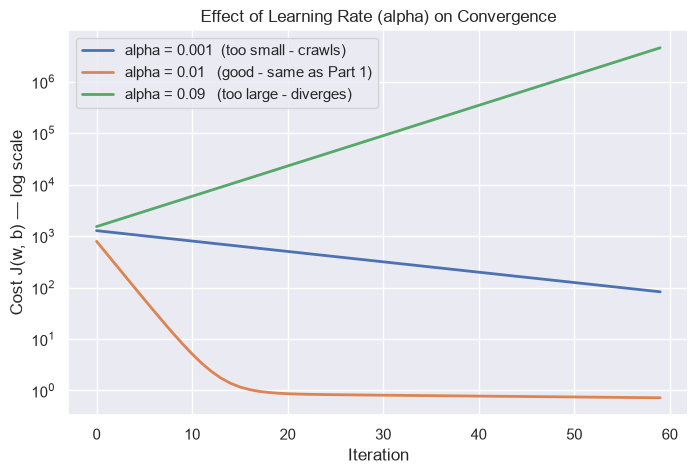

In [39]:
def compute_cost_1d(X, y, w, b):
    m = X.shape[0]
    predictions = w * X + b
    return np.sum((predictions - y) ** 2) / (2 * m)

def gradient_descent_track_cost(X, y, alpha, max_iter=60):
    """Same update rule as Part 1's gradient_descent(), just tracking cost."""
    w, b = 0.0, 0.0
    m = X.shape[0]
    cost_history = []
    for i in range(max_iter):
        predictions = w * X + b
        error = predictions - y
        dj_dw = np.sum(error * X) / m
        dj_db = np.sum(error) / m
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost_1d(X, y, w, b))
    return cost_history

# Reusing Part 1's dataset (Years of Experience -> Salary)
X_demo = np.array([1, 3, 4, 6, 7])
y_demo = np.array([15, 35, 45, 65, 75])

learning_rates = {
    "alpha = 0.001  (too small - crawls)":    0.001,
    "alpha = 0.01   (good - same as Part 1)": 0.01,
    "alpha = 0.09   (too large - diverges)":  0.09,
}

plt.figure(figsize=(8, 5))
for label, alpha in learning_rates.items():
    cost_history = gradient_descent_track_cost(X_demo, y_demo, alpha, max_iter=60)
    plt.plot(cost_history, label=label, linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Cost J(w, b) — log scale")
plt.title("Effect of Learning Rate (alpha) on Convergence")
plt.legend()
plt.yscale("log")
plt.show()

Notice the pattern:
- **$\alpha = 0.001$** is still high after 60 iterations — heading the
  right way, just far too slowly.
- **$\alpha = 0.01$** — the exact value used back in Part 1 — drops toward
  zero fast and stays low. This is why it was chosen.
- **$\alpha = 0.09$** shoots *upward*, off the scale. The steps are so
  large that every update overshoots and makes things worse.

**Rule of thumb:** if the cost is decreasing but slowly, try increasing
$\alpha$ (e.g. 3x). If the cost is oscillating or exploding, decrease it
(e.g. 10x). Repeat until you find the largest $\alpha$ that still converges
smoothly — that reaches the answer fastest without diverging.

## 4.5 Hyperparameter #2 — Number of Iterations (`max_iter`)

The other knob in Part 1's `gradient_descent()`. It decides how many update
steps we take before stopping.

- **Too few** → we stop before reaching the bottom of the cost bowl (the
  model was still improving when we quit — a form of underfitting).
- **Too many** → wasted computation once the cost has flattened out. For
  linear regression's convex, bowl-shaped cost this is harmless, just
  slow — unlike in neural networks, extra iterations here can't cause
  *overfitting*, since there's only one minimum to find.
- **A common alternative**: instead of a fixed count, stop automatically
  once the cost stops improving by more than a tiny threshold between
  steps — this is exactly what scikit-learn's `tol` parameter does, below.
- **One more small one — initial values of `w` and `b`** (`w_input`, `b_input`
  in Part 1's function signature): technically a hyperparameter too, since
  you choose it before training starts. For linear regression specifically
  it barely matters *where* you start (the cost bowl is convex — one lowest
  point, reachable from anywhere), only *how many iterations* it takes to
  get there. This stops being true for non-convex problems like neural
  networks, where the starting point can matter a great deal.

## 4.6 Hyperparameters in Scikit-Learn's `SGDRegressor`

`SGDRegressor` is our Part 1/2 gradient descent, made production-ready — so
it exposes several more hyperparameters:

| Hyperparameter | What it controls | Why you'd tune it |
|---|---|---|
| `alpha` | **Regularization strength** (a different `alpha` than the learning rate, despite the same symbol!) | Higher → simpler model, weights shrink toward zero, less overfitting. Lower → fits the training data more closely. |
| `penalty` | Type of regularization: `'l2'`, `'l1'`, `'elasticnet'`, or `None` | `l2` shrinks weights smoothly; `l1` can push some weights to *exactly* zero (automatic feature selection); `elasticnet` blends both. |
| `learning_rate` | The step-size **schedule**: `'constant'`, `'optimal'`, `'invscaling'`, `'adaptive'` | `'constant'` behaves like our Part 1 code; the others shrink the step size over time, often converging more reliably. |
| `eta0` | The initial learning rate (used when `learning_rate` isn't `'optimal'`) | Same role as `alpha` in Part 1 — too high diverges, too low crawls. |
| `max_iter` | Maximum number of passes over the data | Same idea as Part 1's `max_iter`. |
| `tol` | Stop early once improvement between iterations is smaller than this | Saves time — no point training once the model has effectively converged. |

### `alpha` (regularization) in action
Let's fit the same Part 2/3 dataset with three regularization strengths and
watch the weights shrink:

In [40]:
X_multi = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [5, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])
y_multi = np.array([45.9, 76.55, 92.35, 107.9, 128.])

# Same data as Part 2/3 - only the regularization strength (alpha) changes
for alpha in [0.0001, 1.0, 100.0]:
    model = SGDRegressor(penalty="l2", alpha=alpha, max_iter=10000,
                          learning_rate="constant", eta0=0.01, random_state=42)
    model.fit(X_multi, y_multi)
    print(f"alpha={alpha:<8} -> weights={np.round(model.coef_, 2)}  "
          f"bias={round(model.intercept_[0], 2):<6}  ||w||={np.linalg.norm(model.coef_):.2f}")

alpha=0.0001   -> weights=[ 6.72  8.41 -0.68  1.6 ]  bias=0.64    ||w||=10.91
alpha=1.0      -> weights=[ 6.52  8.06 -0.38  1.78]  bias=3.95    ||w||=10.53
alpha=100.0    -> weights=[-0.84 -1.08 -0.02 -0.34]  bias=75.28   ||w||=1.41


As `alpha` climbs from `0.0001` to `100`, the size of the weight vector
(`||w||`) keeps shrinking — the model is pushed toward a flatter, simpler
line, even though it fits the training data a little worse. This trade-off
(fit vs. simplicity) is exactly what a regularization hyperparameter is
for.

## 4.7 Hyperparameters in Scikit-Learn's `LinearRegression`

By contrast, `LinearRegression` barely has any hyperparameters to tune —
and that's not a limitation, it's a consequence of *how* it solves the
problem.

| Hyperparameter | What it controls | Why you'd tune it |
|---|---|---|
| `fit_intercept` | Whether to compute `b` at all (default `True`) | Set `False` only if you know the line must pass through the origin. |
| `positive` | Force all weights to be ≥ 0 | Useful when negative coefficients would make no real-world sense. |
| `n_jobs` | Parallelization for large multi-target problems | A speed knob, not a modeling knob. |

**Why so few?** `LinearRegression` doesn't search step-by-step like
gradient descent — it solves the cost function directly with a closed-form
formula (the Normal Equation). There's no "step size" or "iteration count"
because there's no searching to do; the answer is computed in one shot.
This is also *why* `SGDRegressor` exists: as data grows very large, the
closed-form computation gets expensive, so we trade the exact-in-one-shot
approach for an iterative one — and pick up all those extra hyperparameters
as the price of that trade.

## 4.8 Quick Reference — Which Hyperparameter Matters Most?

| Priority | Hyperparameter | When it matters |
|---|---|---|
| 🥇 1st | **Learning rate** (`alpha` in Part 1 / `eta0` in `SGDRegressor`) | Always, for any gradient-descent-based training. Get this wrong and nothing else matters. |
| 🥈 2nd | **Regularization strength** (`alpha` in `SGDRegressor`) | When you have many features, noisy data, or the model overfits. |
| 🥉 3rd | **`max_iter` / `tol`** | When training is clearly unfinished (cost still dropping) or wastefully long (cost long flat). |
| Rarely | `fit_intercept`, `positive`, `penalty` type, `n_jobs` | Only in specific situations dictated by your data or domain knowledge. |

**One-line summary:** spend most of your tuning effort on the **learning
rate** when using gradient descent, and on **regularization strength** when
you're worried about overfitting. Everything else is a minor adjustment.

## 4.9 The Complete List (Every Remaining Hyperparameter, For Reference)

Sections 4.4–4.7 covered the hyperparameters people actually reach for in
practice. To fully answer "*is that ALL of them?*" — no, scikit-learn
exposes more. Here is every remaining one, straight from the installed
library (`inspect.signature`), so nothing is left out:

### `SGDRegressor` — the rest of the list

| Hyperparameter | Default | What it controls |
|---|---|---|
| `loss` | `'squared_error'` | The cost function itself. `'squared_error'` = MSE (what this whole notebook uses). `'huber'` is less sensitive to outliers; `'epsilon_insensitive'` / `'squared_epsilon_insensitive'` ignore small errors entirely (SVM-style regression). |
| `l1_ratio` | `0.15` | Only used when `penalty='elasticnet'` — the mix between L1 and L2 (`0`=pure L2, `1`=pure L1). |
| `fit_intercept` | `True` | Same idea as in `LinearRegression` — whether to learn a bias `b` at all. |
| `shuffle` | `True` | Reshuffle the training data after every pass, so stochastic gradient descent doesn't see the same order every epoch. |
| `epsilon` | `0.1` | The margin of tolerance, only used by the `huber` / `epsilon_insensitive` losses. |
| `power_t` | `0.25` | Only used when `learning_rate='invscaling'` — controls how fast the step size shrinks over time. |
| `early_stopping` | `False` | If `True`, stop once a held-out validation score stops improving. |
| `validation_fraction` | `0.1` | Slice of training data set aside for that early-stopping check. |
| `n_iter_no_change` | `5` | Epochs of no improvement to wait before stopping (used by `tol` / `early_stopping`). |
| `warm_start` | `False` | If `True`, a new `.fit()` call continues from the previous solution instead of restarting — useful for online/incremental learning. |
| `average` | `False` | If set, returns the *average* of the weights seen across iterations instead of the last one — sometimes more stable. |
| `random_state` | `None` | Seeds the shuffling/randomness for reproducible runs. Doesn't change *what* is learned, just makes reruns repeatable. |
| `verbose` | `0` | How much progress logging to print — a debugging aid, not a modeling choice. |

### `LinearRegression` — the rest of the list

| Hyperparameter | Default | What it controls |
|---|---|---|
| `tol` | `1e-06` | Convergence tolerance for the internal solver on very large/ill-conditioned data. Almost never touched. |
| `copy_X` | `True` | Whether to copy `X` before fitting or modify it in place — a memory/safety setting, not a modeling one. |

**Why these barely came up earlier:** almost none of them change *what
line gets learned* on well-behaved data like ours — they change *how fast*,
*how repeatable*, or *how memory-efficient* training is. The ones actually
worth experimenting with are still the ones from 4.4–4.7: learning rate,
regularization strength (`alpha` / `penalty`), and iteration count. (Exact
defaults can shift slightly between scikit-learn versions — the table above
reflects the version installed when this notebook was last run.)

---
# Part 5 — Simple Linear Regression on a Real Dataset (with R²)

Parts 1–4 used a tiny 5-point toy dataset to build intuition for `w`, `b`, cost, and
gradient descent. Now let's apply the *exact same idea* — one feature, one target,
a straight line — to a **real dataset**: the **Diabetes dataset** that ships with
scikit-learn (442 real patients; several baseline physiological measurements; the
target is a quantitative measure of disease progression one year after baseline).

We'll use a single feature, **BMI**, to predict the target, fit it with
scikit-learn's `LinearRegression`, and introduce the most common regression
metric: **R² (coefficient of determination)** — "what fraction of the variance in
`y` does the model explain?"


In [41]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

# scaled=False -> keep the original, human-readable units (age in years, bmi as a
# real BMI value, etc.) instead of scikit-learn's default mean-centered/scaled copy.
diabetes = load_diabetes(scaled=False, as_frame=True)
df_diabetes = diabetes.frame
print(df_diabetes.shape)
df_diabetes.head()


(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


## 5.1 Isolate one feature (BMI) and split train/test

Just like Part 1, we keep `X` as a single feature — this time BMI — but now we hold
out a **test set** so we can honestly evaluate the model on data it never saw
during training (something the tiny 5-point toy example was too small to do).


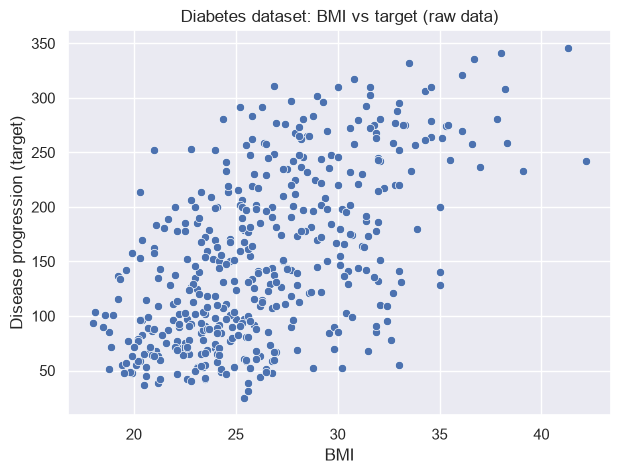

In [42]:
X_simple = df_diabetes[["bmi"]].values    # 2D column shape (n_samples, 1) - what sklearn expects
y_simple = df_diabetes["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_simple.ravel(), y=y_simple)
plt.xlabel("BMI")
plt.ylabel("Disease progression (target)")
plt.title("Diabetes dataset: BMI vs target (raw data)")
plt.show()


## 5.2 Fit with `LinearRegression`, read the coefficients, draw the line

Same model family as Part 3 (`f(x) = wx + b`), just fit on real, noisy data instead
of 5 hand-picked points.


Learned line:  target = 10.763 * BMI + -131.874
Interpretation: each +1 unit of BMI is associated with a 10.76-point increase in the target, holding nothing else fixed (there's nothing else in this single-feature model).


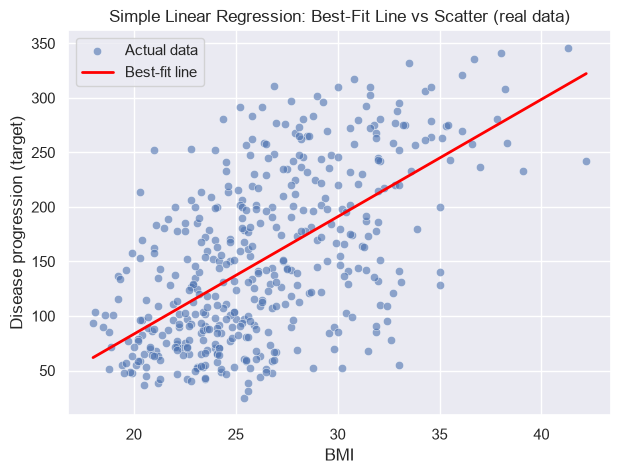

In [43]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

w_simple = simple_model.coef_[0]
b_simple = simple_model.intercept_

print(f"Learned line:  target = {w_simple:.3f} * BMI + {b_simple:.3f}")
print(f"Interpretation: each +1 unit of BMI is associated with a "
      f"{w_simple:.2f}-point increase in the target, holding nothing else fixed "
      f"(there's nothing else in this single-feature model).")

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_simple.ravel(), y=y_simple, label="Actual data", alpha=0.6)
x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
plt.plot(x_line, simple_model.predict(x_line), color="red", linewidth=2, label="Best-fit line")
plt.xlabel("BMI")
plt.ylabel("Disease progression (target)")
plt.title("Simple Linear Regression: Best-Fit Line vs Scatter (real data)")
plt.legend()
plt.show()


## 5.3 R² — how good is the fit?

$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} $$

`R²` compares our model's squared error (`SS_res`) against the squared error of the
dumbest possible model — always predicting the mean `ȳ` (`SS_tot`). `R² = 1` is a
perfect fit; `R² = 0` means the model is no better than predicting the mean;
negative is possible on unseen data if the model is worse than that.


In [44]:
y_pred_test = simple_model.predict(X_test)

r2_sklearn = simple_model.score(X_test, y_test)   # built-in R^2
r2_metric  = r2_score(y_test, y_pred_test)         # same thing via sklearn.metrics

# Manual R^2 = 1 - SS_res / SS_tot, computed straight from the formula above
ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2_manual = 1 - ss_res / ss_tot

print(f"R^2 (model.score) : {r2_sklearn:.4f}")
print(f"R^2 (r2_score)    : {r2_metric:.4f}")
print(f"R^2 (manual)      : {r2_manual:.4f}")
print(f"RMSE              : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"MAE               : {mean_absolute_error(y_test, y_pred_test):.2f}")


R^2 (model.score) : 0.2334
R^2 (r2_score)    : 0.2334
R^2 (manual)      : 0.2334
RMSE              : 63.73
MAE               : 52.26


All three `R²` values agree (as they must — they're the same formula computed
three ways). Notice `R²` here is modest: BMI alone only explains a slice of the
variance in disease progression. That's expected — real outcomes usually depend on
*several* factors at once, which is exactly what Part 6 tackles next.


---
# Part 6 — Multiple Linear Regression on a Real Dataset (R², Adjusted R², Residuals)

BMI alone left most of the variance unexplained. Let's use **all 10 features** in
the Diabetes dataset — `age`, `sex`, `bmi`, `bp` (blood pressure), and six blood
serum measurements `s1`–`s6` — and see how much more of the target we can explain.


In [45]:
feature_cols = [c for c in df_diabetes.columns if c != "target"]
X_multi_real = df_diabetes[feature_cols].values
y_multi_real = df_diabetes["target"].values

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi_real, y_multi_real, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(Xm_train, ym_train)

coef_table = pd.Series(multi_model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
print("Intercept (b):", round(multi_model.intercept_, 3))
print("\nCoefficients (sorted by |effect|):")
print(coef_table.round(3))


Intercept (b): -341.378

Coefficients (sorted by |effect|):
s5     67.109
sex   -23.064
s4     10.160
bmi     5.846
s1     -1.282
bp      1.197
s2      0.811
s3      0.602
s6      0.202
age     0.138
dtype: float64


### Interpreting the coefficients

Each coefficient is the change in the target for **+1 unit** of that feature,
*holding all other features fixed*. For example, a positive `bmi` coefficient means
higher BMI is associated with more disease progression, all else equal — but
**careful**: because `age`, `bp`, `bmi`, `s1`–`s6` are all in different raw units
(years, mmHg, kg/m², blood-serum concentrations…), the raw coefficient *size* is
**not** directly comparable across features. To rank features by importance fairly,
standardize (z-score) them first so the coefficients are on the same scale — a
common pitfall (see README §15).


## 6.2 R² and Adjusted R²

$$ R^2_{adj} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1} $$

where `n` = number of samples and `p` = number of features. Plain `R²` **never
decreases** when you add more features (even useless ones) — Adjusted `R²` adds a
penalty for extra features, so it only goes up if the new feature earns its keep.
Comparing it against Part 5's single-feature `R²` tells us whether the extra 9
features were actually worth it.


In [46]:
ym_pred_test = multi_model.predict(Xm_test)

n_test = Xm_test.shape[0]
p_features = Xm_test.shape[1]

r2_multi = r2_score(ym_test, ym_pred_test)
adj_r2_multi = 1 - (1 - r2_multi) * (n_test - 1) / (n_test - p_features - 1)

print(f"R^2 (10 features, test set)          : {r2_multi:.4f}")
print(f"Adjusted R^2 (10 features, test set)  : {adj_r2_multi:.4f}")
print(f"(Recall Part 5's single-feature R^2 was  : {r2_metric:.4f})")
print(f"RMSE : {np.sqrt(mean_squared_error(ym_test, ym_pred_test)):.2f}")
print(f"MAE  : {mean_absolute_error(ym_test, ym_pred_test):.2f}")


R^2 (10 features, test set)          : 0.4526
Adjusted R^2 (10 features, test set)  : 0.3824
(Recall Part 5's single-feature R^2 was  : 0.2334)
RMSE : 53.85
MAE  : 42.79


Using all 10 features roughly doubles `R²` compared to BMI alone — most of these
physiological measurements really do carry independent, useful information about
disease progression.

## 6.3 Residual Diagnostics — Residuals vs Fitted

A **residual** is `actual - predicted`. Plotting residuals against the fitted
(predicted) values is the single most useful diagnostic plot in regression: for a
good linear fit, residuals should look like a random, structureless cloud centered
on zero with roughly constant spread (see README §8 — homoscedasticity & linearity).


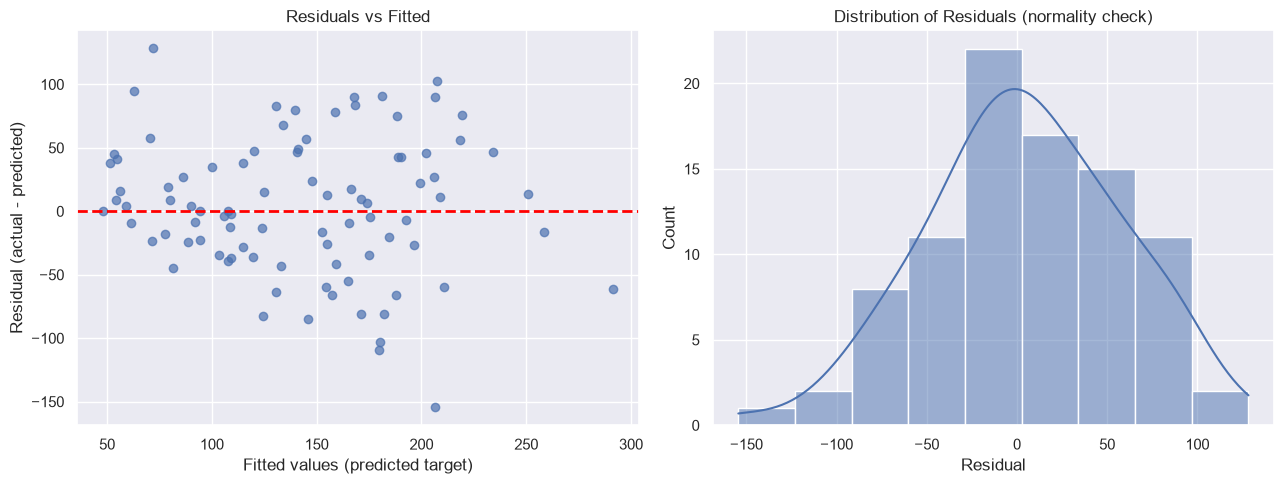

In [47]:
residuals = ym_test - ym_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ym_pred_test, residuals, alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Fitted values (predicted target)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Fitted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel("Residual")
axes[1].set_title("Distribution of Residuals (normality check)")

plt.tight_layout()
plt.show()


**What to look for:**
- **Residuals vs Fitted**: no funnel shape (that would signal heteroscedasticity —
  variance growing with the prediction) and no curve/pattern (that would signal a
  missed non-linear relationship). A random horizontal band is what we want.
- **Distribution of residuals**: roughly bell-shaped/symmetric around zero supports
  the normality-of-errors assumption used for confidence intervals and hypothesis
  tests on the coefficients.


---
# Part 7 — Manual OLS via the Normal Equation (Closed-Form Solution)

Parts 1–2 found `w` and `b` iteratively with gradient descent. But linear
regression's least-squares problem has an exact, **closed-form** solution — the
**Normal Equation**:

$$ \boldsymbol{\beta} = (X^{\mathsf{T}}X)^{-1}X^{\mathsf{T}}y $$

Here `X` includes an extra column of `1`s so that the first entry of `β` becomes
the intercept `b`, and the rest are the feature weights `w`. Let's compute it by
hand with plain NumPy on Part 1's small dataset and confirm it lands on **exactly**
the same numbers as scikit-learn's `LinearRegression` (which uses this same normal
equation — or a numerically-safer equivalent — under the hood).


In [48]:
# Reuse Part 1's tiny dataset: Years of Experience -> Salary
X_small = np.array([1, 3, 4, 6, 7], dtype=float)
y_small = np.array([15, 35, 45, 65, 75], dtype=float)

m = X_small.shape[0]

# Build the design matrix: a column of 1s (for the intercept) + the feature column
X_design = np.column_stack([np.ones(m), X_small])
print("Design matrix X (first column = 1s for the intercept):")
print(X_design)

# The Normal Equation: beta = (X^T X)^-1 X^T y
beta_manual = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_small
b_manual, w_manual = beta_manual[0], beta_manual[1]

print(f"\nManual normal-equation result:  w = {w_manual:.6f},  b = {b_manual:.6f}")


Design matrix X (first column = 1s for the intercept):
[[1. 1.]
 [1. 3.]
 [1. 4.]
 [1. 6.]
 [1. 7.]]

Manual normal-equation result:  w = 10.000000,  b = 5.000000


In [49]:
# Compare against scikit-learn's LinearRegression on the exact same data
sklearn_check = LinearRegression()
sklearn_check.fit(X_small.reshape(-1, 1), y_small)

print(f"scikit-learn result:            w = {sklearn_check.coef_[0]:.6f},  "
      f"b = {sklearn_check.intercept_:.6f}")

assert np.isclose(w_manual, sklearn_check.coef_[0]), "Slopes don't match!"
assert np.isclose(b_manual, sklearn_check.intercept_), "Intercepts don't match!"
print("\nManual normal-equation solution MATCHES scikit-learn exactly.")


scikit-learn result:            w = 10.000000,  b = 5.000000

Manual normal-equation solution MATCHES scikit-learn exactly.


Two completely different routes — hand-rolled gradient descent (Part 1),
plain-NumPy normal equation (here), and scikit-learn's optimized internals (Part
3) — all converge on the *same* line, because for ordinary least squares the cost
function is convex with a single global minimum: there is only one correct answer,
and every valid method eventually finds it.


---
# Part 8 — Multicollinearity Check (Correlation Matrix & VIF)

**Multicollinearity** means two or more input features are strongly correlated
with *each other* (not just with the target). It doesn't hurt predictions much,
but it makes individual coefficients unstable and hard to interpret — see README
§8 for the full explanation. Let's check the Diabetes dataset's 10 features for it.


## 8.1 Correlation matrix (quick visual check)

A simple first pass: pairwise correlation between every feature. Anything close to
`+1` or `-1` (off the diagonal) is a red flag.


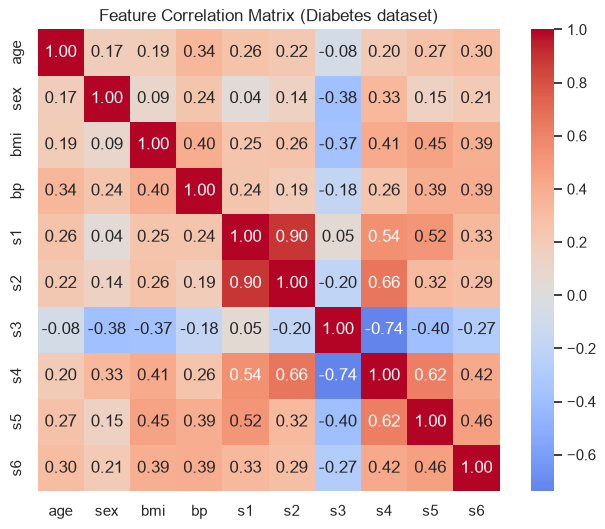

In [50]:
corr_matrix = df_diabetes[feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix (Diabetes dataset)")
plt.show()


## 8.2 Variance Inflation Factor (VIF) — the rigorous check

Correlation only catches **pairwise** relationships. VIF catches even a feature
that's a *combination* of several others. For feature `j`:

$$ VIF_j = \frac{1}{1 - R_j^2} $$

where `R_j²` comes from regressing feature `j` against **all the other features**
(not the target!). If `j` is perfectly predictable from the rest, `R_j² → 1` and
`VIF_j → ∞`. We compute this from scratch with `LinearRegression` — no extra
library needed.

**Rule of thumb:** `VIF ≈ 1` → no correlation with other features; `VIF > 5`
(some say `> 10`) → concerning multicollinearity worth addressing (drop a feature,
combine correlated features, or use Ridge regression).


In [51]:
def compute_vif(X_df):
    """Compute the Variance Inflation Factor for every column in X_df."""
    vif_data = {}
    cols = X_df.columns
    for col in cols:
        other_cols = [c for c in cols if c != col]
        X_others = X_df[other_cols].values
        y_target_col = X_df[col].values

        r2_j = LinearRegression().fit(X_others, y_target_col).score(X_others, y_target_col)
        vif_data[col] = 1 / (1 - r2_j) if r2_j < 1 else np.inf
    return pd.Series(vif_data).sort_values(ascending=False)

vif_series = compute_vif(df_diabetes[feature_cols])
print("Variance Inflation Factors (higher = more multicollinearity):")
print(vif_series.round(2))


Variance Inflation Factors (higher = more multicollinearity):
s1     59.20
s2     39.19
s3     15.40
s5     10.08
s4      8.89
bmi     1.51
s6      1.48
bp      1.46
sex     1.28
age     1.22
dtype: float64


`s1` and `s2` (two blood-serum measurements) typically show the highest VIF in
this dataset — they measure closely related things biologically, so this lines up
with domain knowledge. If VIFs like these showed up in a real project, the fix
would be: drop one of the pair, combine them (e.g. their average or a PCA
component), or switch to Ridge regression, which handles correlated features
gracefully via its L2 penalty (see README §12).


---
# Part 9 — Polynomial Regression: When the Data Isn't a Straight Line

Linear regression fits a straight line, but the *technique* (least squares on a
weighted sum of inputs) extends naturally to curves — just feed it engineered
non-linear features (`x²`, `x³`, …) instead of raw `x`. The model is still "linear"
in its *parameters* `w`; only the *inputs* became non-linear. This is
`PolynomialFeatures` + `LinearRegression`.


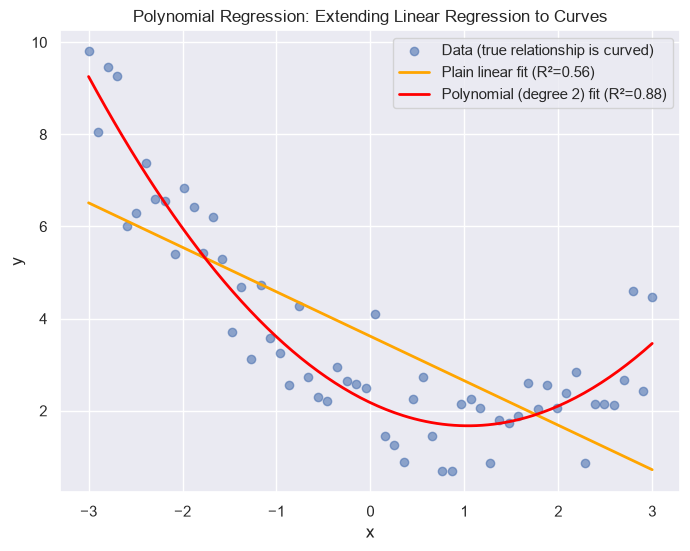

Plain linear regression R^2      : 0.5620
Polynomial (degree 2) R^2        : 0.8847
Polynomial coefficients (x, x^2) : [ 0.         -0.96589258  0.46486088]
Polynomial intercept             : 2.1743


In [52]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Synthetic curved data: y = 0.5x^2 - x + 2 + noise
rng = np.random.default_rng(42)
x_curve = np.linspace(-3, 3, 60)
y_curve = 0.5 * x_curve**2 - x_curve + 2 + rng.normal(scale=1.0, size=x_curve.shape[0])
X_curve = x_curve.reshape(-1, 1)

# 1) Plain linear regression - forced to draw a straight line through curved data
linear_fit = LinearRegression().fit(X_curve, y_curve)
r2_linear_fit = linear_fit.score(X_curve, y_curve)

# 2) Polynomial regression (degree 2) - engineer x^2 as an extra feature, then it's
#    just ordinary linear regression again, now on [x, x^2]
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_curve, y_curve)
r2_poly_fit = poly_model.score(X_curve, y_curve)

x_smooth = np.linspace(-3, 3, 200).reshape(-1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x_curve, y_curve, alpha=0.6, label="Data (true relationship is curved)")
plt.plot(x_smooth, linear_fit.predict(x_smooth), color="orange", linewidth=2,
         label=f"Plain linear fit (R²={r2_linear_fit:.2f})")
plt.plot(x_smooth, poly_model.predict(x_smooth), color="red", linewidth=2,
         label=f"Polynomial (degree 2) fit (R²={r2_poly_fit:.2f})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression: Extending Linear Regression to Curves")
plt.legend()
plt.show()

print(f"Plain linear regression R^2      : {r2_linear_fit:.4f}")
print(f"Polynomial (degree 2) R^2        : {r2_poly_fit:.4f}")
print(f"Polynomial coefficients (x, x^2) : {poly_model.named_steps['linearregression'].coef_}")
print(f"Polynomial intercept             : {poly_model.named_steps['linearregression'].intercept_:.4f}")


The plain straight line **underfits** — it systematically misses the curve at
both ends (its `R²` is visibly lower). Adding `x²` as a feature lets the *same*
`LinearRegression` machinery capture the curve almost perfectly, because the model
is still linear *in the weights* `[w₁, w₂]` — we just gave it a richer set of
inputs. This is the bridge from plain linear regression to feature engineering,
and eventually to more flexible models.

⚠️ **Caution:** higher polynomial degrees fit the training data ever more closely
but easily **overfit** — the curve starts chasing noise instead of the underlying
trend. Always check the fit degree against a held-out test set, not just the
training `R²`.


---
# Summary & Key Takeaways

1. **The model**: Linear regression fits $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$.
   $w$ controls the slope(s), $b$ shifts the line up/down.

2. **The cost function** (Mean Squared Error) gives us a single number measuring how
   wrong the model is. Lower cost = better fit. It forms a convex, U-shaped surface.

3. **Gradient Descent** finds the bottom of that U automatically: compute the
   gradient, take a small step ($\alpha$) against it, repeat. As it converges, the
   gradients shrink toward zero and the parameters stop changing.

4. **Simple → Multiple**: moving from one feature to many changes almost nothing —
   the weight becomes a vector and we use the dot product. The prediction, cost, and
   gradient-descent logic stay the same.

5. **Scikit-Learn** is the practical tool: `LinearRegression` for an exact
   closed-form solution, and `SGDRegressor` (Stochastic Gradient Descent) for very
   large datasets. Both reproduce the parameters we derived from scratch.

6. **Real-world use & tuning**: linear regression shows up anywhere you're predicting
   a number from inputs (pricing, forecasting, scoring), and is valued for being fast
   and interpretable. The learning rate ($\alpha$) is the hyperparameter to get right
   first; regularization strength is the one to reach for if the model overfits.
7. **Real-data validation (Part 5-6)**: the same simple/multiple regression ideas were
   re-run on scikit-learn's real Diabetes dataset. A single feature (BMI) gave a modest
   R²; using all 10 features roughly doubled it — Adjusted R² confirmed the extra
   features earned their keep rather than just inflating R² for free.

8. **Normal Equation (Part 7)**: linear regression's least-squares problem has a
   closed-form solution, $\beta = (X^TX)^{-1}X^Ty$. Computed by hand with plain NumPy,
   it matched scikit-learn's `LinearRegression` output exactly — gradient descent,
   the normal equation, and scikit-learn's solver are three routes to the same unique
   answer.

9. **Multicollinearity (Part 8)**: correlated *input* features (checked via a
   correlation matrix and Variance Inflation Factor, VIF) don't hurt predictions much
   but make individual coefficients unstable and hard to trust. High VIF → consider
   dropping/combining features or switching to Ridge regression.

10. **Residual diagnostics (Part 6.3)**: plotting residuals vs fitted values (and their
    distribution) is the fastest way to sanity-check the linearity, homoscedasticity,
    and normality assumptions behind linear regression's confidence intervals and
    p-values.

11. **Polynomial regression (Part 9)**: the same linear-regression machinery
    (`LinearRegression`) can fit curves once we hand it engineered non-linear features
    (`x²`, `x³`, ...) via `PolynomialFeatures` — the model stays linear *in its
    weights*, only the inputs become non-linear.
